In [1]:
# ==========================================================
# 멀티변량 시계열 기반 설비 고장 조기 예측 + 품질 원인 분류 멀티태스크 모델
# ==========================================================

# 목표:
# 1. 제조 설비 센서 데이터를 시뮬레이션
# 2. 시계열 윈도우를 생성
# 3. 1D CNN + BiLSTM + Attention 기반 멀티태스크 모델을 학습
# 4. 고장 여부(이진분류)와 원인 분류(멀티클래스)를 동시에 수행
# 5. 모델, 스케일러, 학습 이력, 예측 결과를 저장
# 6. 저장된 모델을 다시 불러와 신규 데이터 예측을 수행
# 7. 학습 결과와 예측 결과를 시각화
# ==========================================================

In [5]:
import numpy as np  # 수치 연산
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, MaxPooling2D
from tensorflow.keras.layers import Bidirectional, LSTM, GlobalAveragePooling1D
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.models import Model

# 학습 제어 콜백을 불러온다
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)

In [23]:
#앙상블로  ??? : : :
#하드웨어에 발생하는 소음 음향으로 고장 여부 진단
#원격진단
#임상실험데이터 공유 사이트에서 그 과정 데이터, 결과 데이터,
#최적의 임상시험의 의료레시피 추천

# ==========================================================
# 1. 데이터 설정
# ==========================================================

# 전체 시뮬레이션 샘플 수를 정의
n_sequences = 4000

# 한 시퀸스의 길이를 정의
seq_len = 60

# 센서 개수를 정의
n_features = 6

# 품질 원인 클래스 수를 정의
n_cause_classes = 4

# 센서 이름을 정의
feature_names = ['temperature', 'pressure', 'vibration', 'current', 'speed', 'thickness']

In [24]:
# ==========================================================
#
# ==========================================================

# 하나의 시퀸스를 생성하는 함수를 정의
def generate_sequence(seq_len, mode, cause_class):
    # 시계열을 0부터 1까지 균등 분할하여 생성
    t = np.linspace(0, 1, seq_len)

    # temperature 기본 패턴 생성
    temperature = 50 + 3 * np.sin(2 * np.pi * 2 * t) + np.random.normal(0, 0.6, seq_len)

    # pressure 기본 패턴 생성
    pressure = 100 + 5 * np.cos(2 * np.pi * 1.5 * t) + np.random.normal(0, 0.8, seq_len)

    # vibration 기본 패턴 생성
    vibration = 10 + 0.5 * np.sin(2 * np.pi * 6 * t) + np.random.normal(0, 0.3, seq_len)

    # current 기본 패턴 생성
    current = 20 + 1.2 * np.sin(2 * np.pi * 3 * t) + np.random.normal(0, 0.4, seq_len)

    # speed 기본 패턴 생성
    speed = 1500 + 25 * np.cos(2 * np.pi * 2.5 * t) + np.random.normal(0, 5, seq_len)

    # thickness 기본 패턴 생성
    thickness = 1.20 + 0.02 * np.sin(2 * np.pi * 1.2 * t) + np.random.normal(0, 0.01, seq_len)

    # 정상 모드가 아니라면 이상 패턴을 삽입
    if mode == "fault":
        # 원인 클래스 0이면 온도와 전류 상승 패턴을 삽입
        if cause_class == 0:
            temperature += np.linspace(0, 10, seq_len)
            current += np.linspace(0, 8, seq_len)

        # 원인 클래스 1이면 압력 급상승과 두께 편차를 삽입
        elif cause_class == 1:
            pressure += np.linspace(0, 18, seq_len)
            thickness += np.linspace(0, 0.10, seq_len)
    
        # 원인 클래스 2이면 진동 증가와 속도 저하를 삽입
        elif cause_class == 2:
            vibration += np. linspace(0, 6, seq_len)
            speed -= np.linspace(0, 160, seq_len)
    
    
        # 원인 클래스 3이면 복합 이상 패턴을 삽입
        elif cause_class == 3:
            temperature += np.linspace(0, 6, seq_len)
            pressure += np.linspace(0, 10, seq_len)
            vibration += np.linspace(0, 3, seq_len)
            current += np.linspace(0, 4, seq_len)

    # 생성된 각 센서를 열 방향으로 쌓아 하나의 2차원 시퀸스로 만듬
    sequence = np.column_stack([temperature, pressure, vibration, current, speed, thickness])

    # 생성된 시퀸스를 반환
    return sequence

In [25]:
# ==========================================================
# 3. 전체 데이터셋 생성
# ==========================================================

# 입력 시퀀스를 저장할 리스트를 생성
X_list = []

# 고장 여부 라벨을 저장할 리스트를 생성
y_fault_list = []

# 원인 클래스 라벨을 저장할 리스트를 생성
y_cause_list = []

# 전체 샘플 수 만큼 반복
for i in range(n_sequences):
    mode = np.random.choice(["normal", "fault"], p=[0.7, 0.3])  # 70%는 정상, 30%능 이상이 되도록 랜덤하게 모드를 선택

    if mode == "normal":
        cause_class = 0

    # 이상일 경우 1~3 중 하나를 원인 클래스로 사용
    else:
        cause_class = np.random.choice([1, 2, 3])

    # 시퀀스를 생성
    seq = generate_sequence(seq_len=seq_len, mode=mode, cause_class=cause_class)

    # 입력 리스트에 시퀀스를 추가
    X_list.append(seq)

    # 고장 여부 라벨을 추가, 정상은 0, 이상은 1
    y_fault_list.append(0 if mode == "normal" else 1)

    # 원인 클래스 라벨을 추가
    y_cause_list.append(cause_class)

# 입력 리스트를 numpy 배열로 변환
X = np.array(X_list)
# >????
y_fault = np.array(y_fault_list)

# 원인 클래스 라벨을 numpy로 변환
y_cause = np.array(y_cause_list)


# 고장 여부 라벨 shape를 출력
print("y_fault shape:", y_fault.shape)

# 원인 라벨 shape를 출력
print("y_cause shape:", y_cause.shape)

# 고장 여부 클래스 분포를 출력
print("Fault label distribution:\n", pd.Series(y_fault).value_counts().sort_index())

# 원인 클래스 분포를 출력
print("Cause label distribution:\n", pd.Series(y_cause).value_counts().sort_index())

y_fault shape: (4000,)
y_cause shape: (4000,)
Fault label distribution:
 0    2834
1    1166
Name: count, dtype: int64
Cause label distribution:
 0    2834
1     375
2     394
3     397
Name: count, dtype: int64


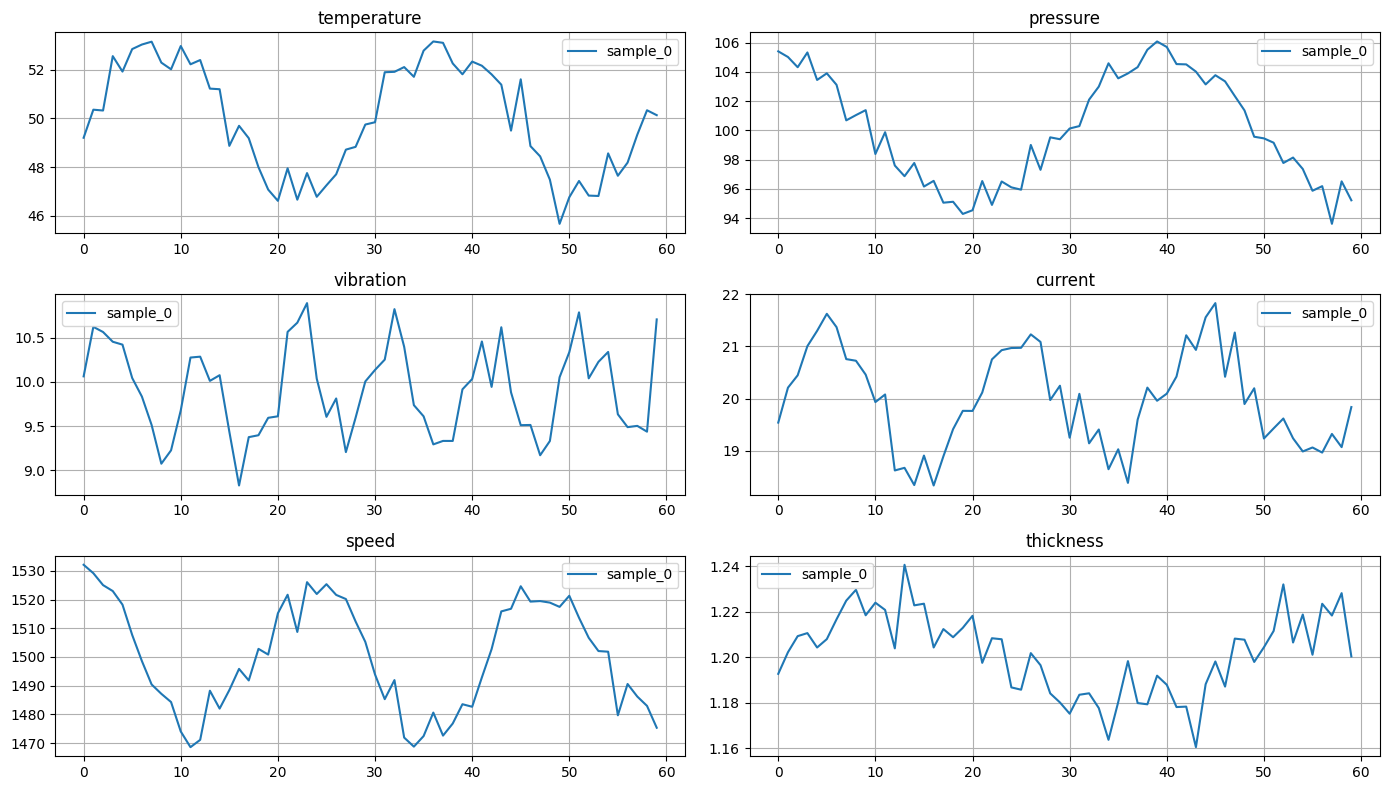

In [26]:
# ---------------------------------------------------------
# 4. 시퀀스 데이터 시각화
# ---------------------------------------------------------

plt.figure(figsize=(14, 8))

# 각 센서별로 subplot을 생성하기 위해 반복
for idx in range(n_features):
    # 3행 2열 구조의 subplot을 생성
    plt.subplot(3, 2, idx + 1)

    # 첫 번째 정상 샘플의 해당 센서 시퀀스를 표시
    plt.plot(X[0, :, idx], label="sample_0")
    plt.title(feature_names[idx])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
# ==========================================================
# 5. 학습 / 검증 / 테스트 데이터 분리
# ==========================================================

# 학습용과 임시용으로 데이터를 분리
X_train, X_temp, y_fault_train, y_fault_temp, y_cause_train, y_cause_temp = train_test_split(
    X, y_fault, y_cause, test_size=0.2, random_state=42, stratify=y_fault
)

# 임시 데이터를 검증용과 테스트용으로 분리
X_val, X_test, y_fault_val, y_fault_test, y_cause_val, y_cause_test = train_test_split(
    X_temp, y_fault_temp, y_cause_temp, test_size=0.5, random_state=42, stratify=y_fault_temp
)

# 분리 결과 shape를 출력
print("Train:", X_train.shape, y_fault_train.shape, y_cause_train.shape)
print("Val  :", X_val.shape, y_fault_val.shape, y_cause_val.shape)
print("Test :", X_test.shape, y_fault_test.shape, y_cause_test.shape)

Train: (3200, 60, 6) (3200,) (3200,)
Val  : (400, 60, 6) (400,) (400,)
Test : (400, 60, 6) (400,) (400,)


In [ ]:
# ==========================================================
# 6. 시계열 데이터 정규화
# ==========================================================

# 시계열 데이터 : (Samples, timestamps, features)
# 시계열 데이터는 3차원 형태이므로 스케일러 적용을 위해 2차원으로 펼쳐야 함
# 먼저 StandardScaler 객체를 생성
scaler = StandardScaler()

# 학습 데이터를 (샘플*시점, 센서수) 형태로 reshape
X_train_2d = X_train.reshape(-1, n_features)

# 검증 데이터를 2차원으로 reshape
X_val_2d = X_val.reshape(-1, n_features)

# 테스트 데이터를 2차원으로 reshape
X_test_2d = X_test.reshape(-1, n_features)

# 학습 데이터 기준으로 스케일러를 학습하고 변환
X_train_scaled_2d = scaler.fit_transform(X_train_2d)

# 검증 데이터를 동일 스케일러로 변환
X_val_scaled_2d = scaler.transform(X_val_2d)

# 테스트 데이터를 동일 스케일러로 변환
X_test_scaled_2d = scaler.transform(X_test_2d)